# Bloque V — Series temporales y forecasting

**Duración estimada:** 3 horas  
**Dataset:** `../data/demanda_diaria_mayo_2026.csv`

## Objetivo de aprendizaje

El alumnado aprenderá a analizar una serie temporal, crear variables temporales, construir modelos baseline y entrenar un modelo de forecasting con Machine Learning.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:25 | Qué es una serie temporal |
| 0:25–0:55 | Indexación y visualización |
| 0:55–1:25 | Tendencia, estacionalidad y ruido |
| 1:25–1:35 | Pausa |
| 1:35–2:05 | Baselines y medias móviles |
| 2:05–2:35 | Forecasting con Machine Learning |
| 2:35–3:00 | Evaluación e interpretación |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    STATSMODELS_OK = True
except Exception:
    STATSMODELS_OK = False

## 1. Carga e indexación temporal

En series temporales el orden de los datos es parte del problema. Por eso convertimos la fecha y la usamos como índice.

In [3]:
df = pd.read_csv("../data/demanda_diaria_mayo_2026.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").set_index("fecha")
df.head()

,demanda,promocion,festivo,temperatura,stock_disponible
fecha,,,,,
2024-01-01,127.470,0,0,10.680,187
2024-01-02,162.170,0,0,4.140,215
2024-01-03,163.880,0,0,9.900,170
2024-01-04,137.810,0,0,13.140,203
2024-01-05,110.730,0,0,7.640,249


## 2. Visualización inicial

El primer paso es representar la serie para detectar tendencia, estacionalidad, ruido y posibles anomalías.

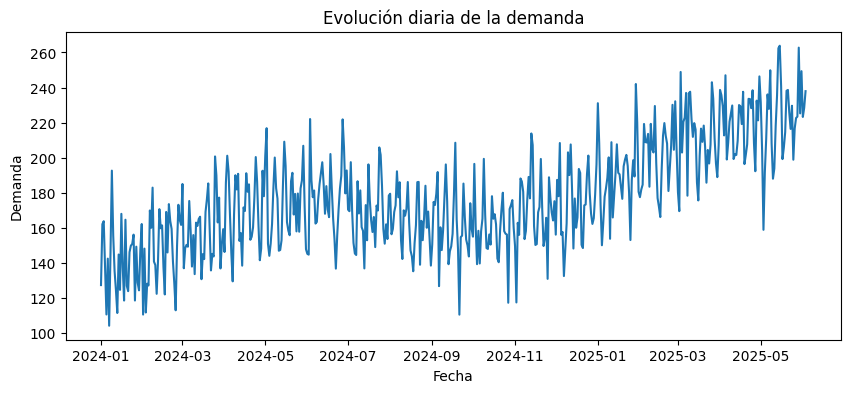

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["demanda"])
plt.title("Evolución diaria de la demanda")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.show()

## 3. Componentes temporales

Una serie temporal puede contener:

- tendencia,
- estacionalidad,
- ruido,
- cambios de nivel,
- picos o anomalías.

Si `statsmodels` está disponible, realizamos una descomposición semanal.

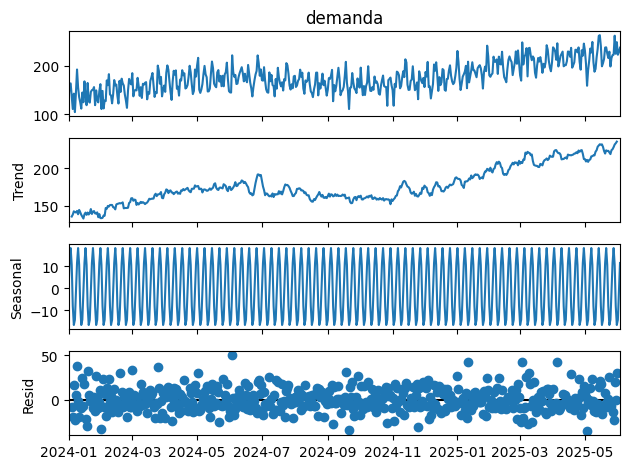

In [5]:
if STATSMODELS_OK:
    descomposicion = seasonal_decompose(df["demanda"], model="additive", period=7)
    descomposicion.plot()
    plt.show()
else:
    print("statsmodels no está disponible en este entorno.")

## 4. Ingeniería de variables temporales

Para aplicar Machine Learning a series temporales, transformamos el tiempo en variables predictoras:

- día de la semana,
- mes,
- variables lag,
- medias móviles,
- variables externas como promoción, festivo o temperatura.

In [6]:
df_features = df.copy()

df_features["dia_semana"] = df_features.index.dayofweek
df_features["mes"] = df_features.index.month
df_features["trimestre"] = df_features.index.quarter
df_features["lag_1"] = df_features["demanda"].shift(1)
df_features["lag_7"] = df_features["demanda"].shift(7)
df_features["lag_14"] = df_features["demanda"].shift(14)
df_features["media_7"] = df_features["demanda"].rolling(window=7).mean()
df_features["media_14"] = df_features["demanda"].rolling(window=14).mean()

df_features.head(15)

,demanda,promocion,festivo,temperatura,stock_disponible,dia_semana,mes,trimestre,lag_1,lag_7,lag_14,media_7,media_14
fecha,,,,,,,,,,,,,
2024-01-01,127.470,0,0,10.680,187,0,1,1,NaN,NaN,NaN,NaN,NaN
2024-01-02,162.170,0,0,4.140,215,1,1,1,127.470,NaN,NaN,NaN,NaN
2024-01-03,163.880,0,0,9.900,170,2,1,1,162.170,NaN,NaN,NaN,NaN
2024-01-04,137.810,0,0,13.140,203,3,1,1,163.880,NaN,NaN,NaN,NaN
2024-01-05,110.730,0,0,7.640,249,4,1,1,137.810,NaN,NaN,NaN,NaN
2024-01-06,142.540,1,0,10.950,244,5,1,1,110.730,NaN,NaN,NaN,NaN
2024-01-07,104.320,0,0,0.140,227,6,1,1,142.540,NaN,NaN,135.560,NaN
2024-01-08,145.950,1,0,5.590,80,0,1,1,104.320,127.470,NaN,138.200,NaN
2024-01-09,192.680,1,0,15.730,88,1,1,1,145.950,162.170,NaN,142.559,NaN


In [7]:
df_modelo = df_features.dropna()
df_modelo.head()

,demanda,promocion,festivo,temperatura,stock_disponible,dia_semana,mes,trimestre,lag_1,lag_7,lag_14,media_7,media_14
fecha,,,,,,,,,,,,,
2024-01-15,124.750,0,0,6.360,83,0,1,1,144.880,145.950,127.470,141.373,139.786
2024-01-16,168.060,0,0,9.290,236,1,1,1,124.750,192.680,162.170,137.856,140.207
2024-01-17,137.640,0,0,4.210,166,2,1,1,168.060,155.660,163.880,135.281,138.333
2024-01-18,118.660,0,0,8.010,223,3,1,1,137.640,135.530,137.810,132.871,136.965
2024-01-19,164.710,1,0,13.210,87,4,1,1,118.660,124.540,110.730,138.610,140.821


## 5. Modelos baseline

Un modelo avanzado debe compararse con una referencia sencilla.

Baseline 1: predicción ingenua con el último valor conocido.  
Baseline 2: media móvil semanal.

In [8]:
df_eval = df_modelo.copy()
df_eval["baseline_naive"] = df_eval["lag_1"]
df_eval["baseline_media_7"] = df_eval["media_7"]

df_eval[["demanda", "baseline_naive", "baseline_media_7"]].head()

,demanda,baseline_naive,baseline_media_7
fecha,,,
2024-01-15,124.750,144.880,141.373
2024-01-16,168.060,124.750,137.856
2024-01-17,137.640,168.060,135.281
2024-01-18,118.660,137.640,132.871
2024-01-19,164.710,118.660,138.610


## 6. Separación temporal train/test

En series temporales no mezclamos aleatoriamente. Entrenamos con el pasado y probamos con el futuro.

In [9]:
horizonte_test = 60

train = df_modelo.iloc[:-horizonte_test]
test = df_modelo.iloc[-horizonte_test:]

print("Train:", train.index.min(), "->", train.index.max())
print("Test:", test.index.min(), "->", test.index.max())

Train: 2024-01-15 00:00:00 -> 2025-04-04 00:00:00
Test: 2025-04-05 00:00:00 -> 2025-06-03 00:00:00


## 7. Evaluación de baselines

In [10]:
def metricas_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_naive, rmse_naive = metricas_forecast(test["demanda"], test["lag_1"])
mae_ma7, rmse_ma7 = metricas_forecast(test["demanda"], test["media_7"])

pd.DataFrame([
    {"modelo": "Naive lag_1", "MAE": mae_naive, "RMSE": rmse_naive},
    {"modelo": "Media móvil 7", "MAE": mae_ma7, "RMSE": rmse_ma7},
])

,modelo,MAE,RMSE
0,Naive lag_1,18.153,22.406
1,Media móvil 7,15.296,19.199


## 8. Forecasting con Random Forest

Usamos variables temporales, lags, medias móviles y variables externas.

In [11]:
features = [
    "dia_semana", "mes", "trimestre",
    "lag_1", "lag_7", "lag_14",
    "media_7", "media_14",
    "promocion", "festivo", "temperatura", "stock_disponible"
]

target = "demanda"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=2
)

modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

mae_rf, rmse_rf = metricas_forecast(y_test, pred_rf)

pd.DataFrame([
    {"modelo": "Naive lag_1", "MAE": mae_naive, "RMSE": rmse_naive},
    {"modelo": "Media móvil 7", "MAE": mae_ma7, "RMSE": rmse_ma7},
    {"modelo": "Random Forest", "MAE": mae_rf, "RMSE": rmse_rf},
]).sort_values("RMSE")

,modelo,MAE,RMSE
2,Random Forest,12.944,16.632
1,Media móvil 7,15.296,19.199
0,Naive lag_1,18.153,22.406


## 9. Visualización real vs predicción

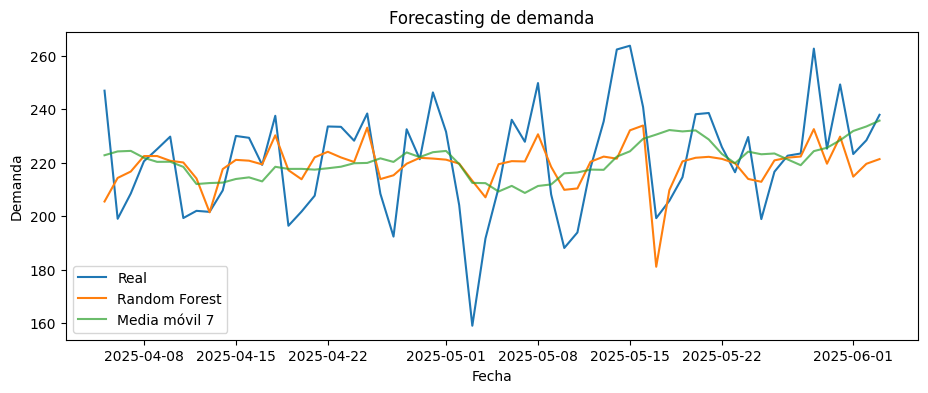

In [12]:
plt.figure(figsize=(11, 4))
plt.plot(y_test.index, y_test, label="Real")
plt.plot(y_test.index, pred_rf, label="Random Forest")
plt.plot(y_test.index, test["media_7"], label="Media móvil 7", alpha=0.7)
plt.title("Forecasting de demanda")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.legend()
plt.show()

## 10. Importancia de variables

La importancia de variables ayuda a interpretar qué factores usa el modelo.

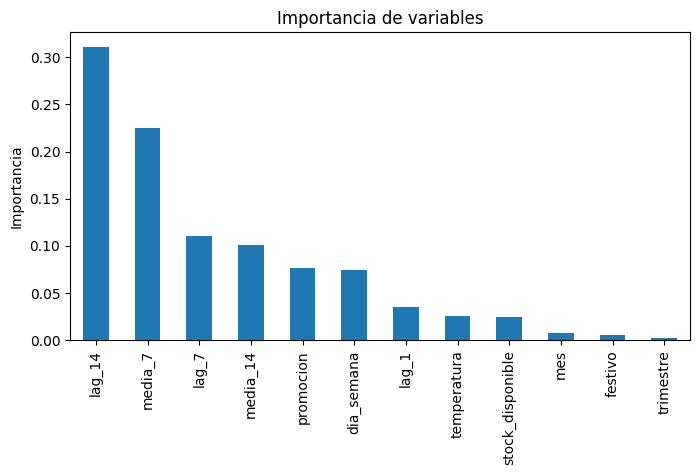

lag_14             0.311
media_7            0.226
lag_7              0.111
media_14           0.101
promocion          0.076
dia_semana         0.075
lag_1              0.035
temperatura        0.026
stock_disponible   0.025
mes                0.008
festivo            0.005
trimestre          0.002
dtype: float64

In [13]:
importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.show()

importancias

## 11. Interpretación

Aspectos que deben discutirse:

- ¿El modelo mejora al baseline?
- ¿Captura bien la tendencia?
- ¿Anticipa picos?
- ¿Suaviza demasiado?
- ¿Qué variables parecen más relevantes?
- ¿Es útil para planificación operativa?

## 12. Ejercicio integrador

1. Cambia el horizonte de test a 30 días.
2. Añade `lag_21`.
3. Cambia la ventana de media móvil a 21 días.
4. Compara los resultados.
5. Representa el nuevo forecast.
6. Redacta una conclusión.

### Entregable

Notebook con tabla comparativa de modelos y gráfico final real vs predicho.

           modelo    MAE   RMSE
2   Random Forest 10.856 14.018
1  Media móvil 21 15.277 19.764
0   Naive (lag_1) 18.282 21.859


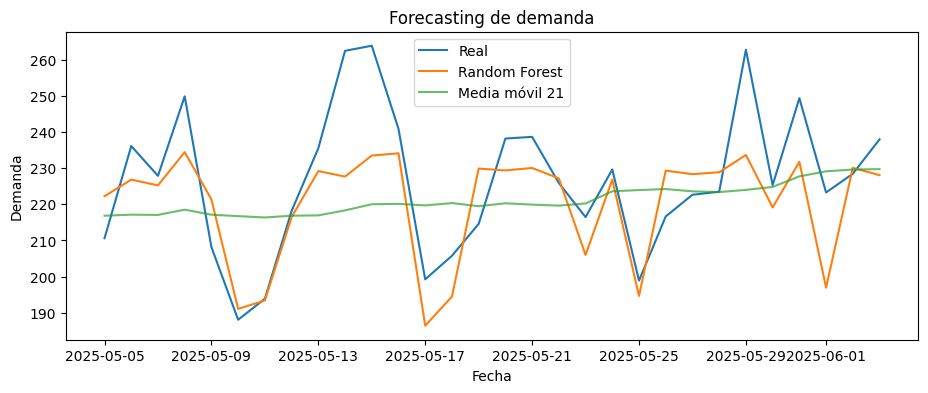

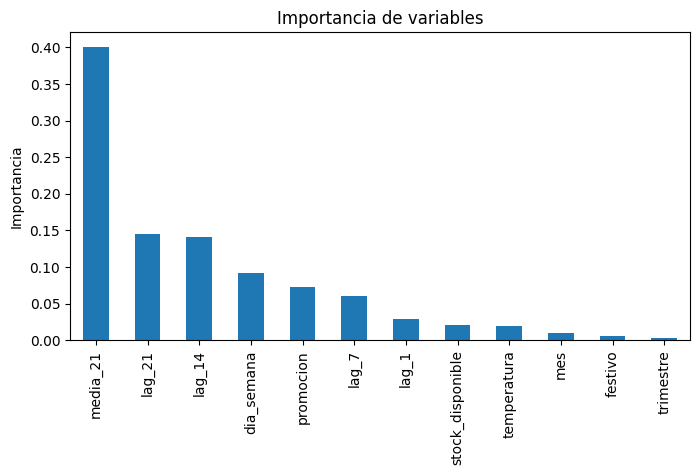

media_21           0.401
lag_21             0.145
lag_14             0.142
dia_semana         0.092
promocion          0.073
lag_7              0.061
lag_1              0.029
stock_disponible   0.020
temperatura        0.020
mes                0.010
festivo            0.006
trimestre          0.003
dtype: float64

CONCLUSIÓN:

En este ejercicio he reducido el horizonte de test a 30 días y he añadido nuevas variables
como lag_21 y una media móvil de 21 días para mejorar el modelo.

Al comparar los resultados, el Random Forest funciona mejor que los baselines, ya que tiene
menos error y se ajusta mejor a los datos reales.

En general, el modelo consigue seguir bastante bien la tendencia, aunque a veces suaviza
los picos y no los predice del todo bien.

Las variables más importantes son los lags y la media móvil, lo que tiene sentido porque
la demanda depende mucho de su comportamiento en días anteriores.

En conclusión, el modelo es bastante útil para predecir la demanda y podría servir 

In [18]:


# ================================
# SPLIT TEMPORAL (30 DÍAS)
# ================================

horizonte_test = 30

train = df_modelo.iloc[:-horizonte_test]  # Datos pasados
test = df_modelo.iloc[-horizonte_test:]   # Datos futuros


# ================================
# MÉTRICAS
# ================================

def metricas_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)  # Error medio absoluto
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Error cuadrático
    return mae, rmse


# ================================
# 6. BASELINES
# ================================

# IMPORTANTE: usamos directamente lag_1 y media_21 del test

mae_naive, rmse_naive = metricas_forecast(
    test["demanda"],
    test["lag_1"]
)

mae_ma21, rmse_ma21 = metricas_forecast(
    test["demanda"],
    test["media_21"]
)


# ================================
# MODELO RANDOM FOREST
# ================================

features = [
    "dia_semana", "mes", "trimestre",
    "lag_1", "lag_7", "lag_14", "lag_21",
    "media_21",
    "promocion", "festivo", "temperatura", "stock_disponible"
]

target = "demanda"

# Separación de variables
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Modelo
modelo_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=2
)

# Entrenamiento
modelo_rf.fit(X_train, y_train)

# Predicción
pred_rf = modelo_rf.predict(X_test)

# Evaluación
mae_rf, rmse_rf = metricas_forecast(y_test, pred_rf)


# ================================
# COMPARACIÓN DE MODELOS
# ================================

resultados = pd.DataFrame([
    {"modelo": "Naive (lag_1)", "MAE": mae_naive, "RMSE": rmse_naive},
    {"modelo": "Media móvil 21", "MAE": mae_ma21, "RMSE": rmse_ma21},
    {"modelo": "Random Forest", "MAE": mae_rf, "RMSE": rmse_rf},
]).sort_values("RMSE")

print(resultados)


# ================================
# GRÁFICO FORECAST
# ================================

plt.figure(figsize=(11, 4))

# Real
plt.plot(y_test.index, y_test, label="Real")

# Predicción modelo
plt.plot(y_test.index, pred_rf, label="Random Forest")

# Baseline
plt.plot(y_test.index, test["media_21"], label="Media móvil 21", alpha=0.7)

plt.title("Forecasting de demanda")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.legend()

plt.show()


# ================================
# IMPORTANCIA DE VARIABLES
# ================================

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.show()

print(importancias)


# ================================
# CONCLUSIÓN
# ================================

print("""
CONCLUSIÓN:

En este ejercicio he reducido el horizonte de test a 30 días y he añadido nuevas variables
como lag_21 y una media móvil de 21 días para mejorar el modelo.

Al comparar los resultados, el Random Forest funciona mejor que los baselines, ya que tiene
menos error y se ajusta mejor a los datos reales.

En general, el modelo consigue seguir bastante bien la tendencia, aunque a veces suaviza
los picos y no los predice del todo bien.

Las variables más importantes son los lags y la media móvil, lo que tiene sentido porque
la demanda depende mucho de su comportamiento en días anteriores.

En conclusión, el modelo es bastante útil para predecir la demanda y podría servir para
tomar decisiones como ajustar stock o planificar mejor.
""")